# **Implementing a Simple MLP for Disease Prediction Using NHANES Dataset**

## **Introduction**

In this assignment, you will preprocess the National Health and Nutrition Examination Survey (NHANES) dataset and implement a simple Multi-Layer Perceptron (MLP) from scratch using NumPy. The goal is to predict the occurrence of either Cancer or Liver disease based on various health and demographic features.

## **Dataset Overview**

The NHANES dataset provides a comprehensive set of health and nutritional data collected through interviews and medical examinations. It includes information on demographics, dietary habits, medical history, and laboratory results.

### **Data Components:**

- **Demographics:** Information about age, gender, ethnicity, etc.
- **Diet:** Dietary intake and related questions.
- **Examination:** Medical and physiological measurements.
- **Labs:** Laboratory test results.

You can refer to the following links for detailed explanations of each component:

- [Demographics](https://wwwn.cdc.gov/Nchs/Nhanes/Search/DataPage.aspx?Component=demographic&CycleBeginYear=2013)
- [Diet](https://wwwn.cdc.gov/Nchs/Nhanes/Search/DataPage.aspx?Component=diet&CycleBeginYear=2013)
- [Examination](https://wwwn.cdc.gov/Nchs/Nhanes/Search/DataPage.aspx?Component=examination&CycleBeginYear=2013)
- [Labs](https://wwwn.cdc.gov/Nchs/Nhanes/Search/DataPage.aspx?Component=labs&CycleBeginYear=2013)

## **Tasks Overview**

1. **Data Preprocessing**
2. **Model Training**
3. **Implementing MLP from Scratch**
4. **Training and Evaluating the Model**

---

## **1. Data Preprocessing**

Data preprocessing is a critical step in any machine learning project. It involves cleaning and transforming raw data to make it suitable for analysis and modeling.

### **1.1. Import Necessary Libraries**


In [1]:
%pip install -U imbalanced-learn

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: imbalanced-learn in c:\dev\home\aihw\project1-decision-tree\project1-decision-tree\venv\lib\site-packages (0.12.4)




[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from scipy import stats
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from imblearn.under_sampling import RandomUnderSampler

### **1.2. Load the Dataset**

You will be provided with four CSV files corresponding to different components of the NHANES dataset. Your first task is to load these datasets.

In [34]:
# ##TODO: Load the datasets into pandas DataFrames


df1 = pd.read_csv('Dataset\demographic.csv') 
df2 = pd.read_csv('Dataset\diet.csv') 
df3 = pd.read_csv('Dataset\examination.csv') 
df4 = pd.read_csv('Dataset\labs.csv')  
# df5 = pd.read_csv('Dataset\questionnaire.csv') 

<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\e'
<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\e'
<>:7: SyntaxWarning: invalid escape sequence '\l'
C:\Users\nazan\AppData\Local\Temp\ipykernel_30732\406375446.py:4: SyntaxWarning: invalid escape sequence '\d'
  df1 = pd.read_csv('Dataset\demographic.csv')
C:\Users\nazan\AppData\Local\Temp\ipykernel_30732\406375446.py:5: SyntaxWarning: invalid escape sequence '\d'
  df2 = pd.read_csv('Dataset\diet.csv')
C:\Users\nazan\AppData\Local\Temp\ipykernel_30732\406375446.py:6: SyntaxWarning: invalid escape sequence '\e'
  df3 = pd.read_csv('Dataset\examination.csv')
C:\Users\nazan\AppData\Local\Temp\ipykernel_30732\406375446.py:7: SyntaxWarning: invalid escape sequence '\l'
  df4 = pd.read_csv('Datas

**Explanation:**

- `df1` to `df4` correspond to Demographics, Diet, Examination, and Labs datasets respectively.
- Use `pd.read_csv()` to load each CSV file.

### **1.3. Merge the Datasets**

After loading the datasets, you need to merge them into a single DataFrame for easier analysis.

In [35]:
# ##TODO: Merge the DataFrames on a common column, typically 'SEQN'
#merged_df = ##TODO
merged_df = pd.merge(df1, df2, on='SEQN', how='inner')
merged_df = pd.merge(merged_df, df3, on='SEQN', how='inner')
merged_df = pd.merge(merged_df, df4, on='SEQN', how='inner')
# merged_df = pd.merge(merged_df, df5, on='SEQN', how='outer')


**Explanation:**

- The `SEQN` column is a unique identifier that can be used to merge the datasets.
- Ensure that the merge is performed correctly to include all relevant data.

### **1.4. Exploratory Data Analysis (EDA)**

Perform EDA to understand the structure and statistical properties of the dataset.

In [36]:
# Display the shape of the dataset
merged_df.shape

# Display basic statistics
merged_df.describe()

# Display the first few rows
merged_df.head()

,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,URXUTL,URDUTLLC,URXUTU,URDUTULC,URXUUR,URDUURLC,URXPREG,URXUAS,LBDB12,LBDB12SI
0,73557,8,2,1,69,NaN,4,4,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,524.0,386.7
1,73558,8,2,1,54,NaN,3,3,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,507.0,374.2
2,73559,8,2,1,72,NaN,3,3,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,732.0,540.2
3,73560,8,2,1,9,NaN,3,3,1.0,119.0,...,0.062,0.0,0.238,0.0,0.0071,0.0,NaN,3.83,NaN,NaN
4,73561,8,2,2,73,NaN,3,3,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,225.0,166.1


**Explanation:**

- Use `.shape` to get the dimensions.
- Use `.describe()` for statistical summary.
- Use `.head()` to view the first few rows.

### **1.5. Handle Columns with Fixed Values**

Remove columns that have only one unique value as they do not contribute to the predictive power.

In [37]:
# ##TODO: Identify and drop columns with only one unique value
dropcols = merged_df.nunique()
columns_to_drop = [col for col in merged_df.columns if merged_df[col].nunique() == 1]
print (columns_to_drop)
# Define a threshold for the number of unique values, for example, drop columns with 1 unique value
#merged_df.nunique() returns a Series where the index is the column names, and the values are the number of unique entries in each column.
#The line merged_df.drop(dropcols, axis=1, inplace=True) will not work directly because dropcols is a Series, not a list or an array of column names.

# Find columns that have less than or equal to the threshold of unique values
merged_df = merged_df.drop(columns=columns_to_drop)
# merged_df.drop(dropcols, axis=1, inplace=True)
# merged_df.describe()
# merged_df.head()

['SDDSRVYR', 'RIDSTATR', 'DRQSDT1', 'DRQSDT2', 'DRQSDT3', 'DRQSDT4', 'DRQSDT6', 'DRQSDT7', 'DRQSDT8', 'DRQSDT9', 'DRQSDT10', 'DRQSDT11', 'DRQSDT12', 'DRQSDT91', 'DRD350K', 'DRD370V', 'BMIRECUM', 'BMILEG', 'BMIARML', 'BMIARMC', 'BMIWAIST', 'CSQ260D', 'CSQ260G', 'CSQ260I', 'CSQ260N', 'CSQ260M', 'URDP02LC', 'LBDBPBLC', 'LBDBSELC', 'LBDBMNLC', 'URDUCSLC', 'URDUMOLC']


**Explanation:**

- Columns with a single unique value are not useful for modeling.
- Identify such columns using `.nunique()` and drop them.

### **1.6. Handle Missing Values and Inconsistencies**

Replace specific codes (`7` and `9`) with `NaN` and handle missing values appropriately.


In [38]:
# Define a function to replace specific patterns with NaN
def replace_with_nan(element):
    try:
        if re.match(pattern, str(int(element))):
            return np.nan
        return element
    except:
        return element

# Replace '7's with NaN
pattern = r'^7+$'
merged_df = merged_df.applymap( replace_with_nan)

# Replace '9's with NaN
pattern = r'^9+$'
merged_df = merged_df.applymap( replace_with_nan)

# Drop columns with more than 30% missing values
threshold = 0.30
missing_percentage = merged_df.isnull().mean()

# Find columns where missing values exceed the threshold
cols_to_drop = missing_percentage[missing_percentage > threshold].index

# Drop the columns with too many missing values
merged_df.drop(cols_to_drop, axis=1, inplace=True)




C:\Users\nazan\AppData\Local\Temp\ipykernel_30732\1653411168.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  merged_df = merged_df.applymap( replace_with_nan)
C:\Users\nazan\AppData\Local\Temp\ipykernel_30732\1653411168.py:16: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  merged_df = merged_df.applymap( replace_with_nan)


**Explanation:**

- Use regex patterns to identify and replace values.
- Drop columns that have a high percentage of missing values to maintain data quality.

### **1.7. Segregate Numerical and Categorical Variables**

Differentiate between numerical and categorical variables for appropriate preprocessing.

In [39]:
# Identify numerical variables
numerical = merged_df.select_dtypes(include=['int64', 'float64'])

print('There are {} numerical variables\n'.format(len(numerical)))
print('The numerical variables are :', numerical)
merged_df[numerical.columns].head()

# Identify categorical variables
categorical = merged_df.select_dtypes(include=['object','int64'])
merged_df[categorical.columns].head()

There are 9813 numerical variables

The numerical variables are :          SEQN  RIAGENDR  RIDAGEYR  RIDRETH1  RIDRETH3  RIDEXMON  DMDBORN4  \
0     73557.0         1      69.0         4       4.0       1.0       1.0   
1     73558.0         1      54.0         3       3.0       1.0       1.0   
2     73559.0         1      72.0         3       3.0       2.0       1.0   
3     73560.0         1       NaN         3       3.0       1.0       1.0   
4     73561.0         2      73.0         3       3.0       1.0       1.0   
...       ...       ...       ...       ...       ...       ...       ...   
9808  83727.0         1      26.0         2       2.0       2.0       1.0   
9809  83728.0         2       2.0         1       1.0       2.0       1.0   
9810  83729.0         2      42.0         4       4.0       2.0       2.0   
9811  83730.0         1       NaN         2       2.0       1.0       1.0   
9812  83731.0         1      11.0         5       6.0       1.0       1.0   

      DMD

,RIAGENDR,RIDRETH1,SIALANG,SIAINTRP,DMDHHSZA,DMDHHSZB,DMDHHSZE,DMDHRGND,SDMVPSU,SDMVSTRA,...,OHX22CTC,OHX23CTC,OHX24CTC,OHX25CTC,OHX26CTC,OHX27CTC,OHX28CTC,OHX29CTC,OHX30CTC,OHX31CTC
0,1,4,1,2,0,0,2,1,1,112,...,P,P,P,P,P,P,P,P,P,P
1,1,3,1,2,0,2,0,1,1,108,...,S,S,S,S,S,S,Z,S,E,E
2,1,3,1,2,0,0,2,1,1,109,...,S,Z,S,S,S,S,S,Z,Z,E
3,1,3,1,2,0,2,0,1,2,109,...,D,S,S,S,S,U,D,D,S,U
4,2,3,1,2,0,0,2,1,2,116,...,S,Z,R,Z,S,Z,E,E,E,E


**Explanation:**

- Numerical variables are typically of type `float64` or `int64`.
- Categorical variables might be of type `object` or `int64` with limited unique values.

### **1.8. Handle Outliers in Numerical Variables**

Detect and visualize outliers in numerical features.

In [40]:
# Check for missing values in numerical variables
merged_df[numerical.columns].isnull().sum()

# View summary statistics
print(round(merged_df[numerical.columns].describe(), 2))

# Function to find columns with outliers
def find_outlier_cols(df):
    outlier_cols = []
    for col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        if df[(df[col] < lower_bound) | (df[col] > upper_bound)].any(axis=None):
            outlier_cols.append(col)
    return outlier_cols

outlier_cols = find_outlier_cols(merged_df[numerical.columns])
print(outlier_cols)
len(outlier_cols), len(numerical)

           SEQN  RIAGENDR  RIDAGEYR  RIDRETH1  RIDRETH3  RIDEXMON  DMDBORN4  \
count   9812.00   9813.00   9350.00   9813.00   9370.00   9813.00   9809.00   
mean   78644.65      1.51     32.54      3.08      3.10      1.51      1.19   
std     2938.73      0.50     24.30      1.26      1.42      0.50      0.39   
min    73557.00      1.00      0.00      1.00      1.00      1.00      1.00   
25%    76091.75      1.00     11.00      2.00      2.00      1.00      1.00   
50%    78643.50      2.00     29.00      3.00      3.00      2.00      1.00   
75%    81191.25      2.00     53.00      4.00      4.00      2.00      1.00   
max    83731.00      2.00     80.00      5.00      6.00      2.00      2.00   

       DMDCITZN  SIALANG  SIAPROXY  ...   LBXHBC   LBDHBG    LBDHD   LBDHEG  \
count   9802.00  9813.00   9812.00  ...  7656.00  7652.00  7652.00  7656.00   
mean       1.09     1.11      1.63  ...     1.94     2.00     2.00     1.96   
std        0.29     0.31      0.48  ...     0.23   

(209, 9813)

**Visualization:**

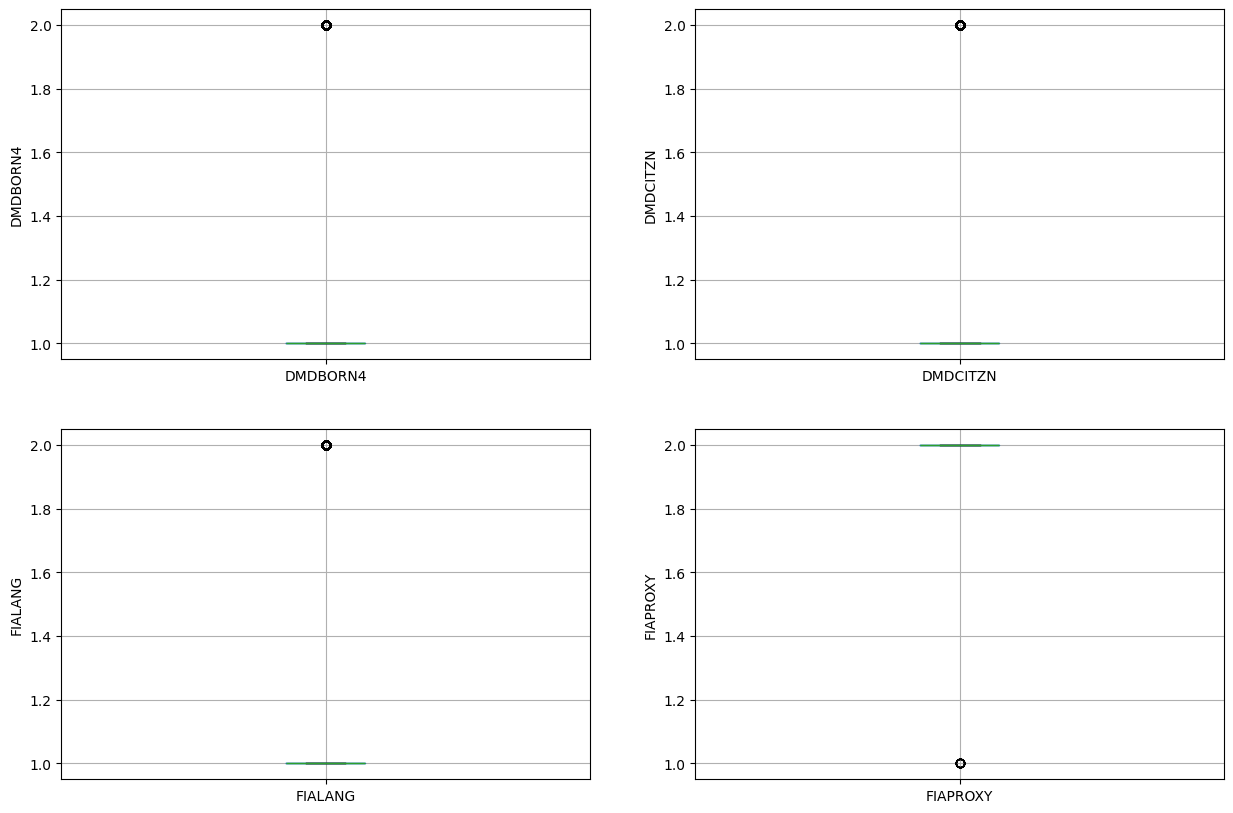

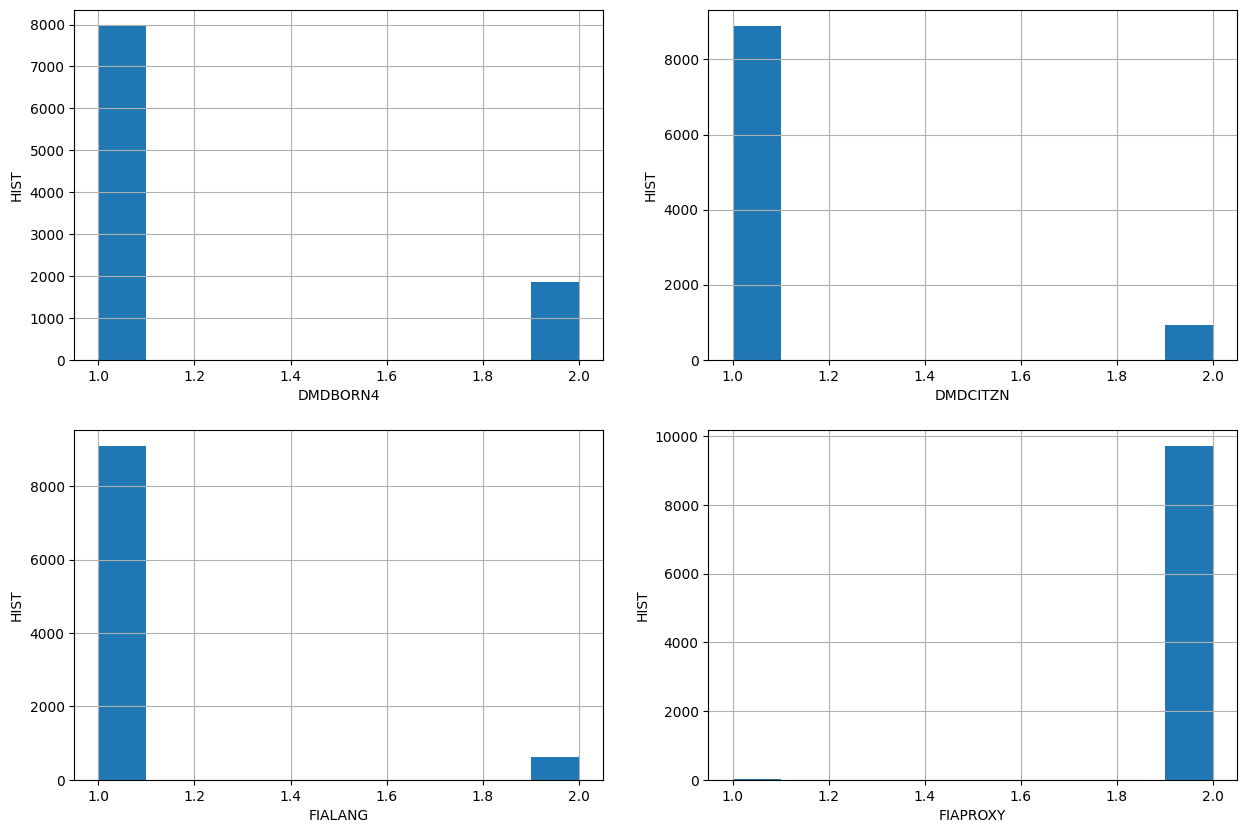

In [41]:
plt.figure(figsize=(15,10))

plt.subplot(2, 2, 1)
fig = merged_df.boxplot(column='DMDBORN4')
fig.set_title('')
fig.set_ylabel('DMDBORN4')

plt.subplot(2, 2, 2)
fig = merged_df.boxplot(column='DMDCITZN')
fig.set_title('')
fig.set_ylabel('DMDCITZN')

plt.subplot(2, 2, 3)
fig = merged_df.boxplot(column='FIALANG')
fig.set_title('')
fig.set_ylabel('FIALANG')

plt.subplot(2, 2, 4)
fig = merged_df.boxplot(column='FIAPROXY')
fig.set_title('')
fig.set_ylabel('FIAPROXY')
plt.show()

plt.figure(figsize=(15,10))

plt.subplot(2, 2, 1)
fig = merged_df.DMDBORN4.hist(bins=10)
fig.set_xlabel('DMDBORN4')
fig.set_ylabel('HIST')

plt.subplot(2, 2, 2)
fig = merged_df.DMDCITZN.hist(bins=10)
fig.set_xlabel('DMDCITZN')
fig.set_ylabel('HIST')

plt.subplot(2, 2, 3)
fig = merged_df.FIALANG.hist(bins=10)
fig.set_xlabel('FIALANG')
fig.set_ylabel('HIST')

plt.subplot(2, 2, 4)
fig = merged_df.FIAPROXY.hist(bins=10)
fig.set_xlabel('FIAPROXY')
fig.set_ylabel('HIST')
plt.show()

**Explanation:**

- Boxplots and histograms help visualize the distribution and detect outliers.
- Outliers can be handled by removing or transforming the data if necessary.

### **1.9. Prepare Target Variables**

Load and preprocess the target variables for Cancer and Liver disease.

In [42]:
# Load the Questionnaire file
target = pd.read_csv('Dataset\questionnaire.csv')

# Replace '7's and '9's with NaN
pattern = r'^9+$'
target = target.applymap(replace_with_nan)
pattern = r'^7+$'
target = target.applymap(replace_with_nan)

# Merge targets with the main dataset
liver_values = target.merge(merged_df, on='SEQN', how='right')[['SEQN', 'MCQ160L']]
cancer_values = target.merge(merged_df, on='SEQN', how='right')[['SEQN', 'MCQ220']]

# # Drop NaN values from target DataFrames
cancer_values.dropna(subset=['MCQ220'], inplace=True)
liver_values.dropna(subset=['MCQ160L'], inplace=True)

# # Merge back to get final datasets
final_liver_data = liver_values.merge(merged_df, on='SEQN', how='left').drop(['SEQN', 'MCQ160L'], axis=1)
final_cancer_data = cancer_values.merge(merged_df, on='SEQN', how='left').drop(['SEQN', 'MCQ220'], axis=1)

# # Drop 'SEQN' from target DataFrames
cancer_values = cancer_values.drop(['SEQN'], axis=1)
liver_values = liver_values.drop(['SEQN'], axis=1)

final_cancer_data.head()
final_liver_data.head()

<>:2: SyntaxWarning: invalid escape sequence '\q'
<>:2: SyntaxWarning: invalid escape sequence '\q'
C:\Users\nazan\AppData\Local\Temp\ipykernel_30732\3542229045.py:2: SyntaxWarning: invalid escape sequence '\q'
  target = pd.read_csv('Dataset\questionnaire.csv')
C:\Users\nazan\AppData\Local\Temp\ipykernel_30732\3542229045.py:6: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  target = target.applymap(replace_with_nan)
C:\Users\nazan\AppData\Local\Temp\ipykernel_30732\3542229045.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  target = target.applymap(replace_with_nan)


,RIAGENDR,RIDAGEYR,RIDRETH1,RIDRETH3,RIDEXMON,DMDBORN4,DMDCITZN,SIALANG,SIAPROXY,SIAINTRP,...,LBXHBC,LBDHBG,LBDHD,LBDHEG,LBDHEM,LBXTC,LBDTCSI,LBXTTG,URXVOL1,URDFLOW1
0,1,69.0,4,4.0,1.0,1.0,1.0,1,2.0,2,...,1.0,2.0,2.0,2.0,2.0,167.0,4.32,2.0,87.0,0.821
1,1,54.0,3,3.0,1.0,1.0,1.0,1,2.0,2,...,2.0,2.0,2.0,2.0,2.0,170.0,4.40,2.0,90.0,1.636
2,1,72.0,3,3.0,2.0,1.0,1.0,1,2.0,2,...,2.0,2.0,2.0,2.0,2.0,126.0,3.26,2.0,66.0,NaN
3,2,73.0,3,3.0,1.0,1.0,1.0,1,2.0,2,...,2.0,2.0,2.0,2.0,2.0,201.0,5.20,2.0,5.0,0.109
4,1,56.0,1,1.0,1.0,1.0,1.0,1,2.0,2,...,2.0,2.0,2.0,2.0,2.0,226.0,5.84,2.0,197.0,1.187


**Explanation:**

- The target variables `MCQ220` (Cancer) and `MCQ160L` (Liver) indicate the presence (`1`) or absence (`2`) of the respective diseases.
- Handle missing values by dropping rows with `NaN` in target variables.

---

## **2. Feature Engineering**

Transform raw data into meaningful features to enhance model performance.

### **2.1. Segregate Categorical and Numerical Features**


In [43]:
# Identify categorical and numerical features for Cancer data
cancer_categorical = final_cancer_data.select_dtypes(include=['object']).columns
print(final_cancer_data[cancer_categorical].head())

cancer_numerical = final_cancer_data.select_dtypes(include=['float64', 'int64']).columns
print(final_cancer_data[cancer_numerical].head())

# Identify categorical and numerical features for Liver data
liver_categorical = final_liver_data.select_dtypes(include=['object']).columns
print(final_liver_data[liver_categorical].head())

liver_numerical = final_liver_data.select_dtypes(include=['float64', 'int64']).columns
print(final_liver_data[liver_numerical].head())

  OHX02CTC OHX03CTC OHX04CTC OHX05CTC OHX06CTC OHX07CTC OHX08CTC OHX09CTC  \
0        P        P        P        P        P        P        P        P   
1        Z        J        S        S        S        S        S        S   
2        Z        Z        Z        S        S        S        S        Z   
3        E        Z        E        Z        Z        Z        R        R   
4        Z        Z        R        Z        R        R        Y        Y   

  OHX10CTC OHX11CTC  ... OHX22CTC OHX23CTC OHX24CTC OHX25CTC OHX26CTC  \
0        P        P  ...        P        P        P        P        P   
1        S        S  ...        S        S        S        S        S   
2        S        S  ...        S        Z        S        S        S   
3        Z        Z  ...        S        Z        R        Z        S   
4        Y        Y  ...        Y        Y        Y        J        Y   

  OHX27CTC OHX28CTC OHX29CTC OHX30CTC OHX31CTC  
0        P        P        P        P        P  


**Explanation:**

- Categorical features are typically of type `object` or have a limited number of unique integer values.
- Numerical features are of type `float64` or have many unique integer values.

### **2.2. Impute Missing Values**

#### **2.2.1. Numerical Features**

Use median imputation for numerical features to handle missing values.


In [44]:
# Impute missing values in Cancer numerical features
for col in cancer_numerical:
    col_median =final_cancer_data[col].median()
    final_cancer_data[col].fillna(col_median ,inplace=True)

# Impute missing values in Liver numerical features
for col in liver_numerical:
    col_median = final_liver_data[col].median()
    final_liver_data[col].fillna(col_median, inplace=True)

print(final_cancer_data[cancer_numerical].isnull().sum())
print(final_liver_data[liver_numerical].isnull().sum())

C:\Users\nazan\AppData\Local\Temp\ipykernel_30732\2649328231.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  final_cancer_data[col].fillna(col_median ,inplace=True)
C:\Users\nazan\AppData\Local\Temp\ipykernel_30732\2649328231.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.



RIAGENDR    0
RIDAGEYR    0
RIDRETH1    0
RIDRETH3    0
RIDEXMON    0
           ..
LBXTC       0
LBDTCSI     0
LBXTTG      0
URXVOL1     0
URDFLOW1    0
Length: 246, dtype: int64
RIAGENDR    0
RIDAGEYR    0
RIDRETH1    0
RIDRETH3    0
RIDEXMON    0
           ..
LBXTC       0
LBDTCSI     0
LBXTTG      0
URXVOL1     0
URDFLOW1    0
Length: 246, dtype: int64


C:\Users\nazan\AppData\Local\Temp\ipykernel_30732\2649328231.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  final_liver_data[col].fillna(col_median, inplace=True)
C:\Users\nazan\AppData\Local\Temp\ipykernel_30732\2649328231.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

**Explanation:**

- Median imputation is robust to outliers and suitable for numerical data.
- Replace `NaN` values with the median of each column.

#### **2.2.2. Categorical Features**

Use mode imputation for categorical features to handle missing values.


In [45]:
# Impute missing values in Cancer categorical features
for col in cancer_categorical:
    col_mode = final_cancer_data[col].mode()[0]
    final_cancer_data[col].fillna(col_mode,inplace=True)

# Impute missing values in Liver categorical features
for col in liver_categorical:
    col_mode =  final_liver_data[col].mode()[0]
    final_liver_data[col].fillna(col_mode,inplace=True)

print(final_cancer_data[cancer_categorical].isnull().sum())
print(final_liver_data[liver_categorical].isnull().sum())

OHX02CTC    0
OHX03CTC    0
OHX04CTC    0
OHX05CTC    0
OHX06CTC    0
OHX07CTC    0
OHX08CTC    0
OHX09CTC    0
OHX10CTC    0
OHX11CTC    0
OHX12CTC    0
OHX13CTC    0
OHX14CTC    0
OHX15CTC    0
OHX18CTC    0
OHX19CTC    0
OHX20CTC    0
OHX21CTC    0
OHX22CTC    0
OHX23CTC    0
OHX24CTC    0
OHX25CTC    0
OHX26CTC    0
OHX27CTC    0
OHX28CTC    0
OHX29CTC    0
OHX30CTC    0
OHX31CTC    0
dtype: int64
OHX02CTC    0
OHX03CTC    0
OHX04CTC    0
OHX05CTC    0
OHX06CTC    0
OHX07CTC    0
OHX08CTC    0
OHX09CTC    0
OHX10CTC    0
OHX11CTC    0
OHX12CTC    0
OHX13CTC    0
OHX14CTC    0
OHX15CTC    0
OHX18CTC    0
OHX19CTC    0
OHX20CTC    0
OHX21CTC    0
OHX22CTC    0
OHX23CTC    0
OHX24CTC    0
OHX25CTC    0
OHX26CTC    0
OHX27CTC    0
OHX28CTC    0
OHX29CTC    0
OHX30CTC    0
OHX31CTC    0
dtype: int64


C:\Users\nazan\AppData\Local\Temp\ipykernel_30732\121271095.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  final_cancer_data[col].fillna(col_mode,inplace=True)
C:\Users\nazan\AppData\Local\Temp\ipykernel_30732\121271095.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

**Explanation:**

- Mode imputation fills missing categorical values with the most frequent category.
- Ensure no missing values remain after imputation.

### **2.3. Encode Categorical Variables**

Convert categorical variables into numerical format using one-hot encoding.


In [46]:
# One-hot encode categorical variables for Cancer data
final_cancer_data = pd.get_dummies(final_cancer_data, columns=cancer_categorical, drop_first=True)


# One-hot encode categorical variables for Liver data
final_liver_data = pd.get_dummies(final_liver_data, columns=liver_categorical, drop_first=True)

**Explanation:**

- Use `pd.get_dummies()` to convert categorical variables into binary indicators.
- This step is essential for feeding categorical data into the MLP.

### **2.4. Feature Selection**

Select the most relevant features based on correlation to reduce dimensionality and improve model performance.


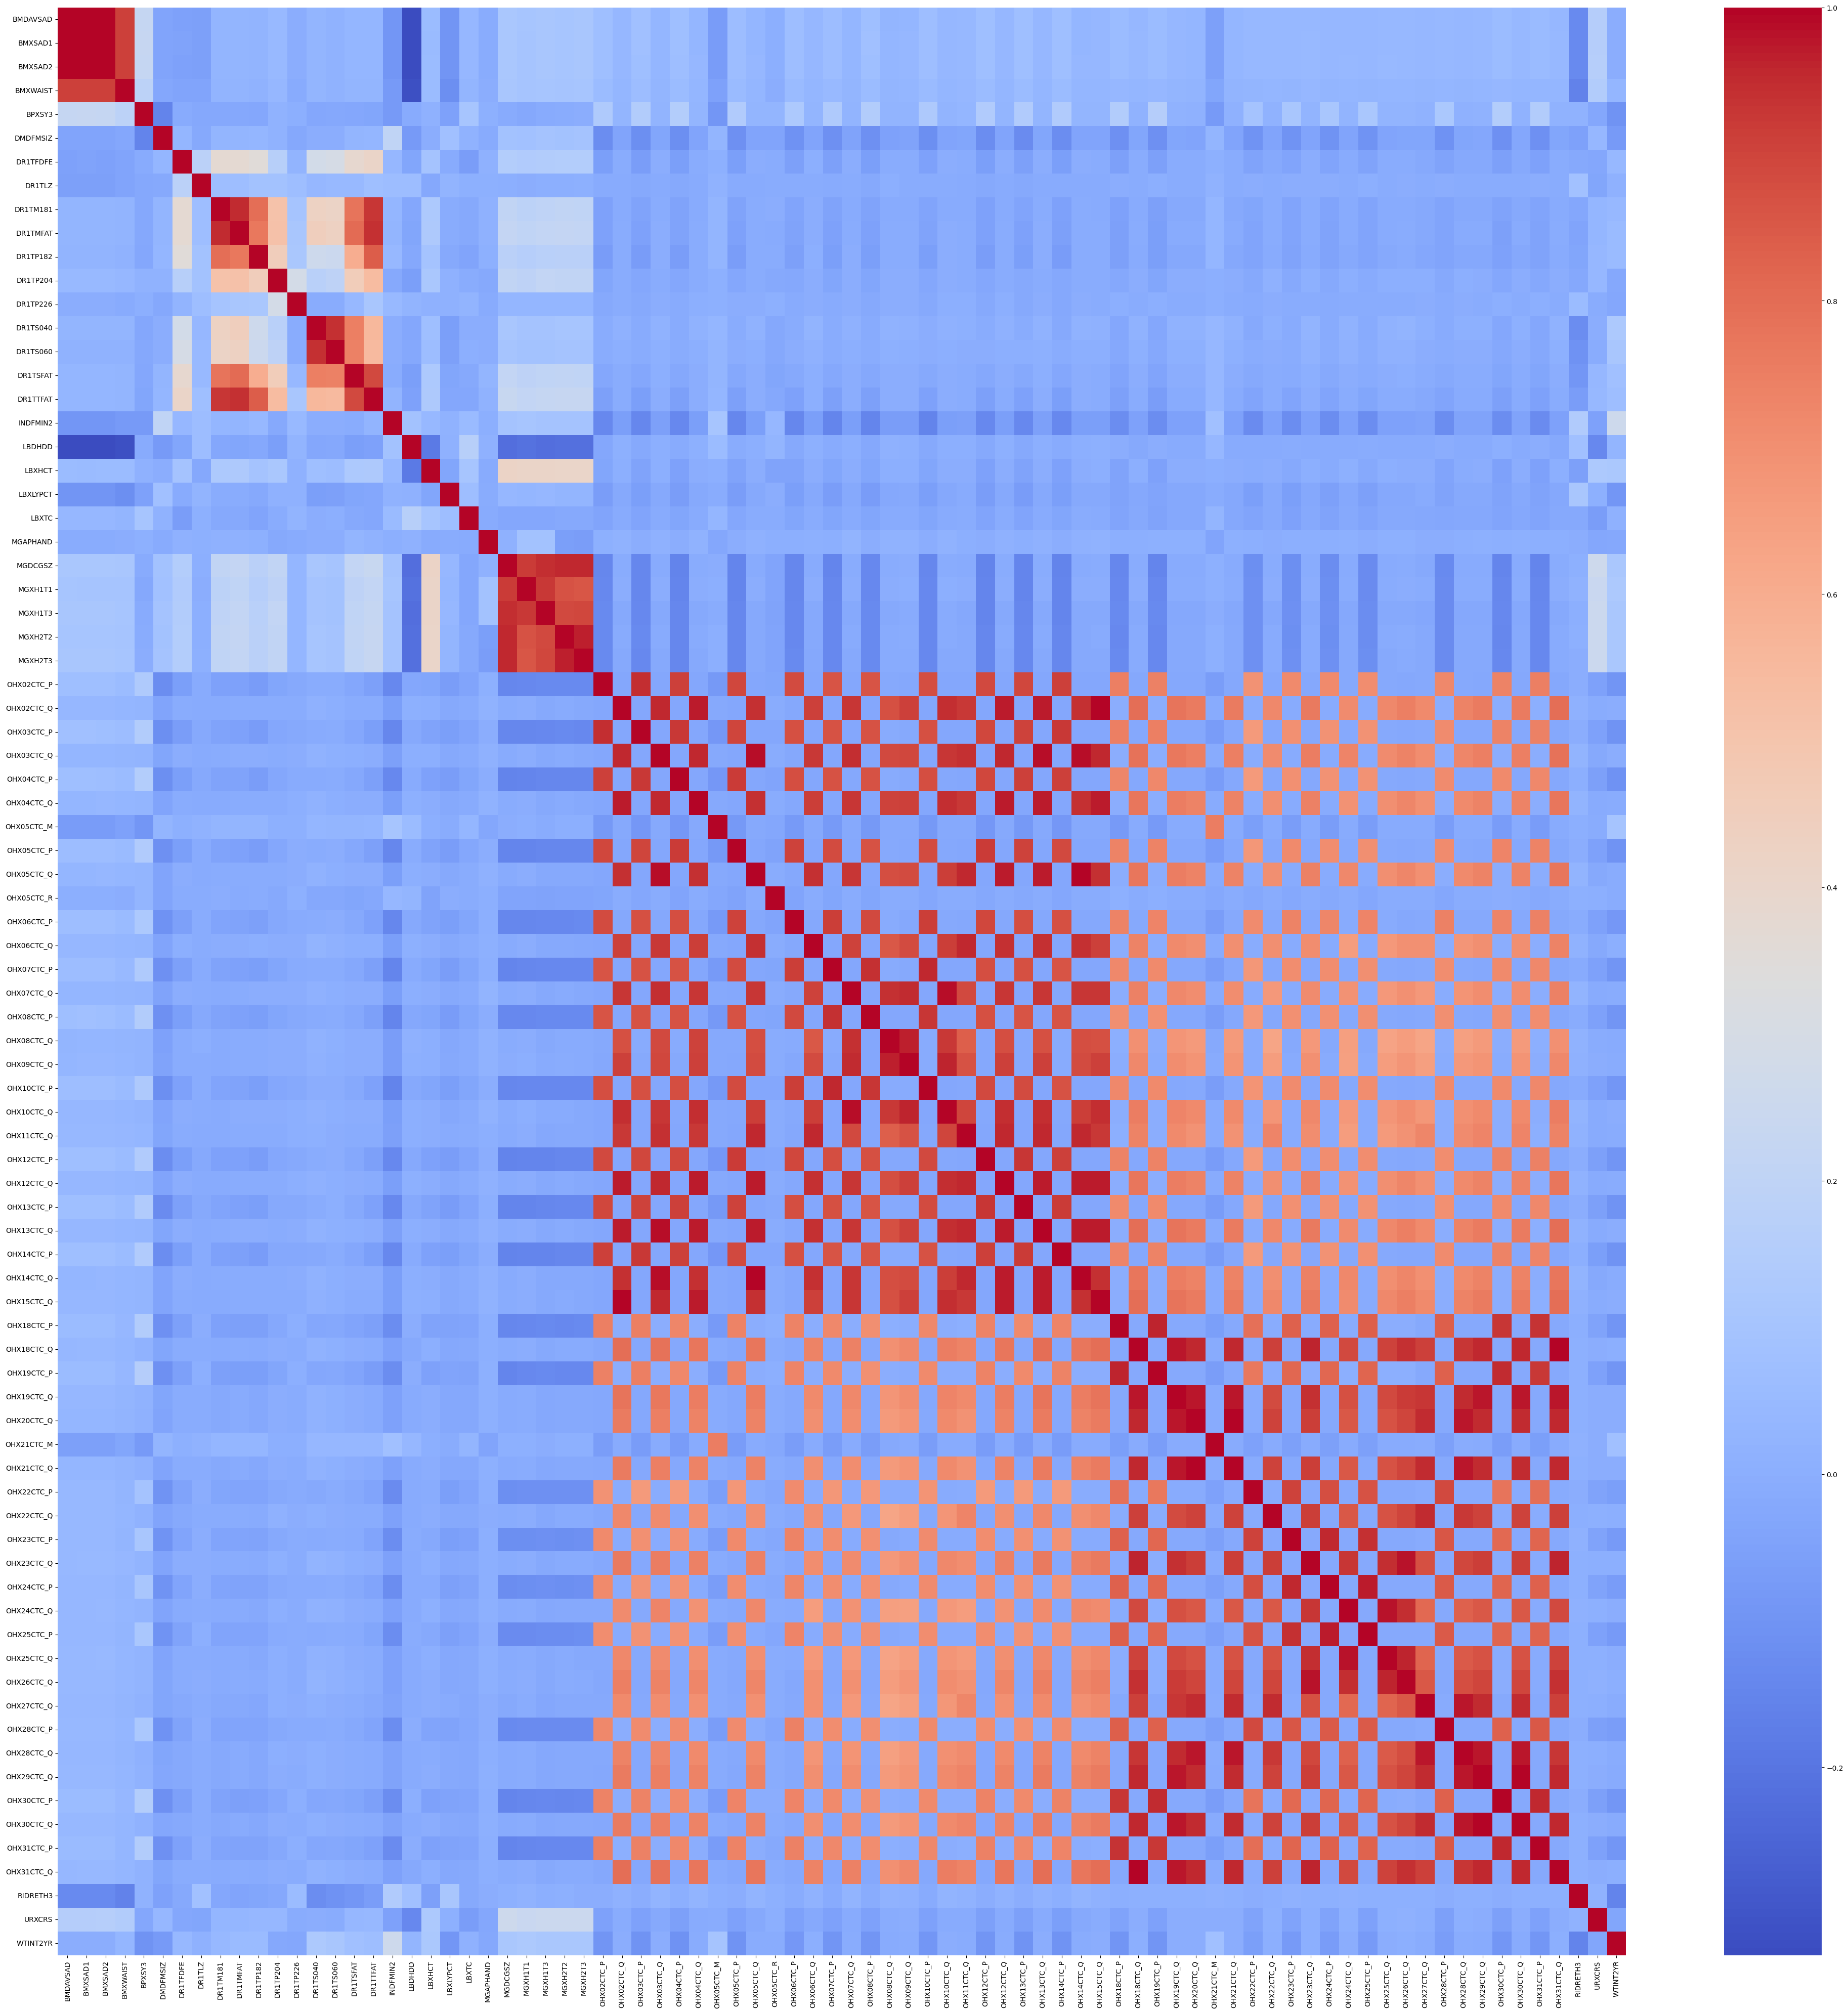

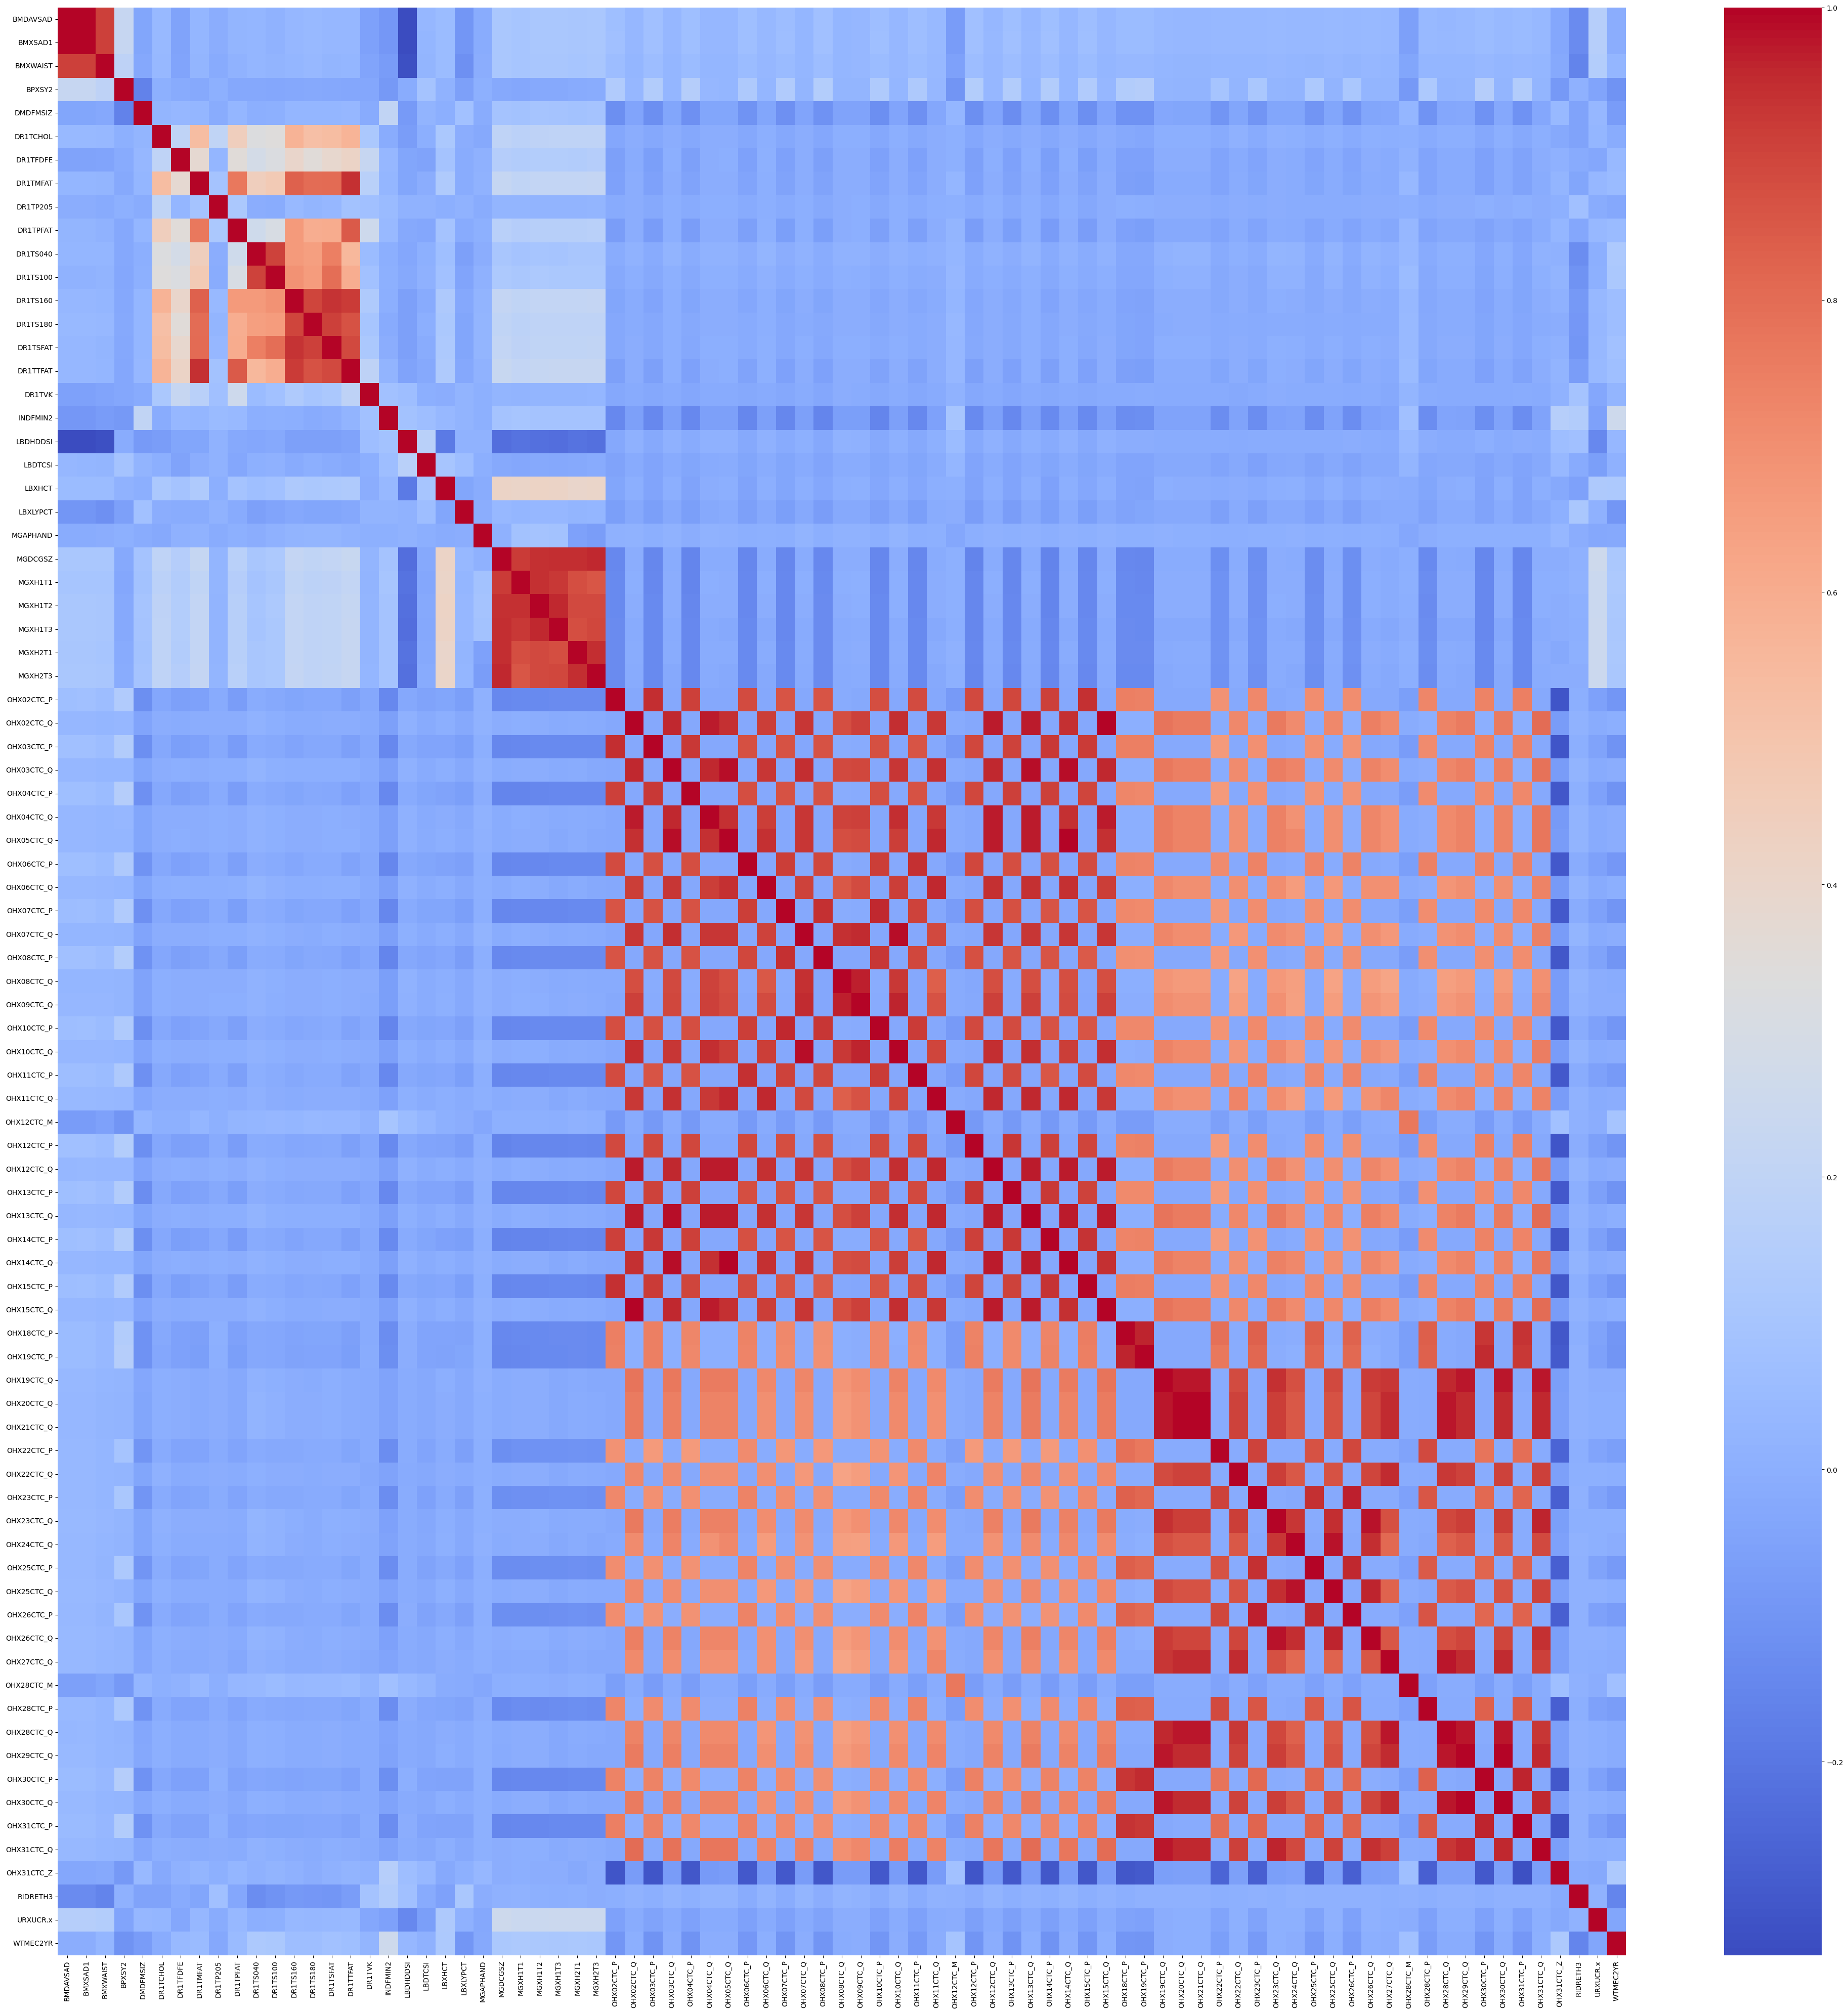

In [47]:
# Compute correlation matrices
cancer_corr_matrix = final_cancer_data.corr()
liver_corr_matrix = final_liver_data.corr()

# Plot heatmaps for Cancer data
abs_corr_matrix = np.abs(cancer_corr_matrix)
cancer_corr_pairs = abs_corr_matrix.unstack().sort_values(ascending=False)
top_pairs = cancer_corr_pairs[:1000]
unique_pairs = top_pairs.drop_duplicates()
top_columns = np.unique([col for col, _ in unique_pairs.keys()])
top_corr_matrix = final_cancer_data[top_columns].corr()

plt.figure(figsize=(50, 50))
sns.heatmap(top_corr_matrix, annot=False, cmap='coolwarm')
plt.show()

# Plot heatmaps for Liver data
abs_corr_matrix = np.abs(liver_corr_matrix)
liver_corr_pairs = abs_corr_matrix.unstack().sort_values(ascending=False)
top_pairs = liver_corr_pairs[:1000]
unique_pairs = top_pairs.drop_duplicates()
top_columns = np.unique([col for col, _ in unique_pairs.keys()])
top_corr_matrix = final_liver_data[top_columns].corr()

plt.figure(figsize=(50, 50))
sns.heatmap(top_corr_matrix, annot=False, cmap='coolwarm')
plt.show()

**Explanation:**

- High correlation between features can lead to multicollinearity.
- Selecting a subset of features with high correlation to the target reduces complexity.

### **2.5. Select Top Features**

Choose 150 features based on their correlation with the target variable.

#### **2.5.1. Cancer Data**


In [48]:
import random

# Set correlation threshold
threshold = 0.8
# cancer_corr_matrix
# Get pairs with correlation higher than threshold
high_corr_pairs = cancer_corr_matrix.where(abs(cancer_corr_matrix)>threshold).stack().items()
print(high_corr_pairs)
# Initialize set for selected features
selected_features = set()

# Select features based on high correlation
for pair, corr in high_corr_pairs:
    selected_feature = random.choice(pair) 
    selected_features.add(selected_feature)
    if len(selected_features) == 150:
        break

# Warning if less than 150 features are selected
if len(selected_features) < 150:
    print(f"Warning: Only {len(selected_features)} features were selected. Consider lowering the threshold.")

# Create DataFrame with selected features
selected_cancer_df = final_cancer_data[list(selected_features)]

#### **2.5.2. Liver Data**

In [49]:
# Set correlation threshold
threshold = 0.8

# Get pairs with correlation higher than threshold
high_corr_pairs =  liver_corr_matrix.where(abs(liver_corr_matrix)>threshold).stack().items()

# Initialize set for selected features
selected_features = set()

# Select features based on high correlation
for pair, corr in high_corr_pairs:
    selected_feature = random.choice(pair)
    selected_features.add(selected_feature)
    if len(selected_features) == 150:
        break

# Warning if less than 150 features are selected
if len(selected_features) < 150:
    print(f"Warning: Only {len(selected_features)} features were selected. Consider lowering the threshold.")

# Create DataFrame with selected features
selected_liver_df = final_liver_data[list(selected_features)]

**Explanation:**

- Features with a correlation higher than the threshold are considered.
- Randomly select one feature from highly correlated pairs to avoid redundancy.
- Ensure that 150 features are selected; adjust the threshold if necessary.

### **2.6. Scale the Features and Apply PCA**

Normalize the data and reduce dimensionality using Principal Component Analysis (PCA).


In [50]:
# Scale and apply PCA for Liver data
cols = selected_liver_df.columns
scaler = StandardScaler()
selected_liver_df = scaler.fit_transform(selected_liver_df)
selected_liver_df = pd.DataFrame(selected_liver_df, columns=[cols])

pca = PCA(0.90)
liverprincipalComponents = pca.fit_transform(selected_liver_df)
liverprincipalDf = pd.DataFrame(data=liverprincipalComponents,
                           columns=['Principal Component ' + str(i) for i in range(1, liverprincipalComponents.shape[1] + 1)])
liverprincipalDf.head()

# Scale and apply PCA for Cancer data
cols = selected_cancer_df.columns
scaler = StandardScaler()
selected_cancer_df = scaler.fit_transform(selected_cancer_df)
selected_cancer_df = pd.DataFrame(selected_cancer_df, columns=[cols])

pca = PCA(0.90)
cancerprincipalComponents = pca.fit_transform(selected_cancer_df)
cancerprincipalDf = pd.DataFrame(data=cancerprincipalComponents,
                           columns=['Principal Component ' + str(i) for i in range(1, cancerprincipalComponents.shape[1] + 1)])
cancerprincipalDf.head()

,Principal Component 1,Principal Component 2,Principal Component 3,Principal Component 4,Principal Component 5,Principal Component 6,Principal Component 7,Principal Component 8,Principal Component 9,Principal Component 10,...,Principal Component 61,Principal Component 62,Principal Component 63,Principal Component 64,Principal Component 65,Principal Component 66,Principal Component 67,Principal Component 68,Principal Component 69,Principal Component 70
0,-3.402542,0.402495,-0.111681,0.572229,0.683952,0.391486,-0.871871,1.812933,-0.860919,-0.180037,...,-0.268211,-0.180637,0.199685,-0.128279,1.299209,0.367577,-0.591534,0.746349,-0.404006,0.679896
1,18.799806,0.880319,4.429829,-3.353115,-0.003312,5.347259,4.929320,2.585457,4.402634,-0.340748,...,3.679311,1.096097,-1.522498,-1.879502,-2.309710,0.341206,-1.562982,1.367485,0.024542,-1.345258
2,-1.195588,2.672117,-1.350163,-1.729723,2.327048,-1.811883,-0.199284,-0.584151,2.206282,-0.473038,...,1.278939,-0.830266,1.467037,0.620561,0.680968,0.585969,1.326595,-0.087462,0.032885,-0.780484
3,-2.227788,-1.072224,-1.337003,-4.849508,2.804209,-1.989517,1.113402,1.049355,1.863594,0.029813,...,-0.774049,-1.251397,0.144089,0.251613,1.272731,-0.193334,-0.747786,-1.834907,1.940050,-0.474766
4,-0.163051,4.860548,2.335344,-2.045582,1.796188,-0.056317,-0.789233,-1.357996,-0.658997,-2.135554,...,-1.201610,-1.581120,-0.688733,-0.627728,0.153176,-0.393605,-0.864547,0.335553,-0.694050,0.864889


**Explanation:**

- `StandardScaler` standardizes features by removing the mean and scaling to unit variance.
- PCA reduces the number of features while retaining 90% of the variance, simplifying the model.

### **2.7. Encode Target Labels**

Convert target labels from `1` and `2` to `0` and `1`.


In [51]:
# Convert Cancer labels: 1 -> 1 (present), 2 -> 0 (absent)
cancer_values[cancer_values == 2] = 0
cancer_values.head()

# Convert Liver labels: 1 -> 1 (present), 2 -> 0 (absent)
liver_values[liver_values == 2] = 0
liver_values.head()

,MCQ160L
0,0.0
1,0.0
2,0.0
4,0.0
5,0.0


**Explanation:**

- Binary classification requires labels to be `0` and `1`.
- Replace `2` with `0` to indicate absence of disease.

### **2.8. Split the Data into Training and Testing Sets**

Divide the dataset into training and testing subsets.


In [52]:
# Split Cancer data
cancer_x_train, cancer_x_test, cancer_y_train, cancer_y_test = train_test_split(
    cancerprincipalDf, cancer_values, test_size=0.2, random_state=0)

# Split Liver data
liver_x_train, liver_x_test, liver_y_train, liver_y_test = train_test_split(
    liverprincipalDf, liver_values, test_size=0.2, random_state=0)

print(cancer_x_train.shape, cancer_x_test.shape, liver_x_train.shape, liver_x_test.shape)

(4470, 70) (1118, 70) (4463, 70) (1116, 70)


**Explanation:**

- Use an 80/20 split for training and testing.
- Ensures that the model is trained on a majority of the data and tested on unseen data.

### **2.9. Handle Class Imbalance**

Use under-sampling to balance the classes in the training data.


In [53]:
# Under-sampling for Liver dataset
rus = RandomUnderSampler(random_state=0)
liver_x_resampled, liver_y_resampled = rus.fit_resample(liver_x_train, liver_y_train)

# Under-sampling for Cancer dataset
rus = RandomUnderSampler(random_state=0)
cancer_x_resampled, cancer_y_resampled = rus.fit_resample(cancer_x_train, cancer_y_train)

**Explanation:**

- Imbalanced datasets can bias the model towards the majority class.
- Under-sampling reduces the size of the majority class to balance the dataset.

---

## **3. Implementing MLP from Scratch**

In this section, you will implement a simple MLP with one hidden layer using NumPy. The network will consist of an input layer, a hidden layer with 10 neurons, and an output layer. The sigmoid activation function will be used, and Binary Cross-Entropy will be the loss function.

### **3.1. Define Data Preprocessor Class**

This class handles splitting the resampled data into training and validation sets.

In [64]:
class DataPreprocessor:
    def __init__(self):
        '''
        Initialize with resampled training data and test data
        '''
        self.X =  cancer_x_resampled.values
        self.y =cancer_y_resampled.values
        self.X_test =cancer_x_test.values
        self.y_test =  cancer_y_test.values
       

    def preprocess(self):
        self.X_train, self.X_val, self.y_train, self.y_val = train_test_split(
            self.X, self.y, test_size=0.2, random_state=42)

**Explanation:**

- Initializes with resampled training data (`X` and `y`) and test data.
- Splits the training data further into training and validation sets for monitoring overfitting.

### **3.2. Define MLP Class**

This class defines the structure and operations of the MLP.


In [65]:
class MLP:
    def __init__(self, input_size, hidden_size, output_size):
        '''
        Initialize weights and biases
        '''
        #changing 0.01 to 0.0001 
        self.weights1 = np.random.randn(input_size, hidden_size) * 0.0001
        self.bias1 = np.zeros((1, hidden_size))
        self.weights2 = np.random.randn(hidden_size, output_size) * 0.0001
        self.bias2 =  np.zeros((1, output_size)) 

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def sigmoid_derivative(self, x):
        '''
        Implement the derivative of the sigmoid function
        '''
        return x * (1 - x)

    def forward(self, X):
        '''
        Perform forward propagation
        '''
        self.z1 =np.dot(X,self.weights1)   + self.bias1
        self.a1 = self.sigmoid(self.z1)
        self.z2 =np.dot(self.a1, self.weights2)   +self.bias2
        self.a2 =self.sigmoid(self.z2)
        return self.a2

    def backward(self, X, y, output, learning_rate):
        '''
        Perform backward propagation and update weights and biases
        '''
        m = X.shape[0]  # Number of examples
 
        # Output layer gradients
        dz2 = output-y                   # Error at output layer
        dw2 =  np.dot(self.a1.T, dz2)  # Gradient of weights for output layer
        db2 = np.sum(dz2, axis=0, keepdims=True)   # Gradient of bias for output layer

        # Hidden layer gradients
        dz1 = np.dot(dz2, self.weights2.T) * (self.a1 * (1 - self.a1))  # Error for hidden layer with sigmoid derivative
        dw1 =  np.dot(X.T, dz1)          # Gradient of weights for hidden layer
        db1 = np.sum(dz1, axis=0, keepdims=True) / m  # Gradient of bias for hidden layer

        # Update weights and biases
        self.weights2 -= learning_rate * dw2
        self.bias2 -= learning_rate * db2
        self.weights1 -= learning_rate * dw1
        self.bias1 -= learning_rate * db1


**Explanation:**

- **Initialization (`__init__`):**
  - Initialize weights with small random values.
  - Initialize biases with zeros.
  
- **Activation Functions:**
  - `sigmoid`: Activation function for neurons.
  - `sigmoid_derivative`: Derivative used during backpropagation.
  
- **Forward Propagation (`forward`):**
  - Compute activations for hidden and output layers.
  
- **Backward Propagation (`backward`):**
  - Compute gradients and update weights and biases using Stochastic Gradient Descent (SGD).

### **3.3. Define Trainer Class**

This class handles the training process, including batching, loss calculation, and accuracy monitoring.

In [66]:
class Trainer:
    def __init__(self, model, X_train, y_train, X_val, y_val, epochs=100, learning_rate=0.1, batch_size=32):
        self.model = model
        self.X_train = X_train
        self.y_train = y_train
        self.X_val = X_val
        self.y_val = y_val
        self.epochs = epochs
        self.learning_rate = learning_rate
        self.batch_size = batch_size
        self.train_losses = []
        self.train_accuracies = []
        self.val_losses = []
        self.val_accuracies = []

    def train(self):
        m = self.X_train.shape[0]

        for epoch in range(self.epochs):
            # Shuffle the training data
            indices = np.random.permutation(self.X_train.shape[0])  # Generate shuffled indices
            X_shuffled = self.X_train[indices]
            y_shuffled = self.y_train[indices]

            for i in range(0, m, self.batch_size):
                # Get the current batch
                X_batch = X_shuffled[i:i + self.batch_size]
                y_batch = y_shuffled[i:i + self.batch_size]

                # Forward pass
                output = self.model.forward(X_batch)

                # Backward pass
                self.model.backward(X_batch, y_batch, output, self.learning_rate)

            # Calculate training loss and accuracy
            train_output = self.model.forward(self.X_train)
            y_selected = train_output


            mean_loss = y_selected - self.y_train  # Element-wise subtraction
            train_loss = np.sum(mean_loss)
            

            true_classes = (self.y_train > 0.5).astype(int).flatten()  # Flatten to 1D array if necessary

            # Predicted values based on thresholding
            predicted_classes = (y_selected > 0.5).astype(int).flatten()  # Flatten to 1D array if necessary

            # Calculate the accuracy by comparing both arrays
            train_accuracy = np.mean(predicted_classes == true_classes)


            # Calculate validation loss and accuracy
            val_output = self.model.forward(self.X_val)

            # Convert to NumPy array and reshape (if needed)
            y_selected_val = val_output  # Convert to NumPy array (if val_output is DataFrame)
            

            # Calculate validation loss (element-wise subtraction)
            mean_loss_val = y_selected_val - self.y_val  # Element-wise subtraction
            val_loss = np.sum(mean_loss_val)  # Mean of the validation loss

            # Predicted classes (based on max output)
            predicted_classes_val = (y_selected_val > 0.5).astype(int).flatten()  # Flatten to 1D array

            # True classes from one-hot encoded labels, thresholded for binary classification
            true_classes_val = (self.y_val > 0.5).astype(int).flatten()  # Flatten to 1D array

            # Validation accuracy
            val_accuracy = np.mean(predicted_classes_val == true_classes_val)

            # Store the metrics
            self.train_losses.append(train_loss)
            self.train_accuracies.append(train_accuracy)
            self.val_losses.append(val_loss)
            self.val_accuracies.append(val_accuracy)

            if (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch+1}/{self.epochs}, Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}")

    def plot_results(self):
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.plot(self.train_losses, label='Train')
        plt.plot(self.val_losses, label='Validation')
        plt.title('Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(self.train_accuracies, label='Train')
        plt.plot(self.val_accuracies, label='Validation')
        plt.title('Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()

        plt.tight_layout()
        plt.show()

**Explanation:**

- **Training Process (`train`):**
  - Shuffles the data at each epoch to ensure randomness.
  - Processes data in batches for efficient computation.
  - Performs forward and backward passes to update the model.
  - Calculates and stores loss and accuracy for both training and validation sets.
  
- **Plotting Results (`plot_results`):**
  - Visualizes the loss and accuracy over epochs to monitor training progress and detect overfitting.

### **3.4. Define Tester Class**

This class evaluates the trained model on the test dataset.


In [67]:
class Tester:
    def __init__(self, model, X_test, y_test):
        self.model = model
        self.X_test = X_test
        self.y_test = y_test

    def test(self):
        '''
        Perform testing by forwarding test data through the model and computing loss and accuracy
        '''
        # Forward pass on test data
        test_output = self.model.forward(self.X_test)

        # Select the relevant column and convert to a NumPy array
        y_selected_test = test_output   # Convert to a NumPy array
      

        # Calculate test loss (using element-wise subtraction)
        test_loss = y_selected_test - self.y_test  # Element-wise subtraction
        mean_test_loss = np.mean(test_loss)        # Mean of the test loss

        # True classes (binary classification, thresholded)
        true_classes_test = (self.y_test > 0.5).astype(int)

        # Predicted classes (thresholding on the output)
        predicted_classes_test = (y_selected_test > 0.5).astype(int)
        
        # Calculate the test accuracy by comparing both arrays
        test_accuracy = np.mean(predicted_classes_test == true_classes_test)


        print(f"Test Loss: {mean_test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

        return test_output

**Explanation:**

- **Testing Process (`test`):**
  - Performs a forward pass with the test data.
  - Computes the Binary Cross-Entropy loss and accuracy.
  - Prints and returns the test results.

---

## **4. Training and Evaluating the Model**

Finally, you will tie everything together to train and evaluate your MLP model.

### **4.1. Main Execution**

Epoch 10/100, Train Loss: 2.8434, Train Acc: 0.8158, Val Loss: -3.3537, Val Acc: 0.7469
Epoch 20/100, Train Loss: -61.2655, Train Acc: 0.8220, Val Loss: -20.4225, Val Acc: 0.7531
Epoch 30/100, Train Loss: -10.6418, Train Acc: 0.8591, Val Loss: -8.9949, Val Acc: 0.7407
Epoch 40/100, Train Loss: -31.8718, Train Acc: 0.8777, Val Loss: -16.1933, Val Acc: 0.7346
Epoch 50/100, Train Loss: 14.6284, Train Acc: 0.9195, Val Loss: -2.6174, Val Acc: 0.7099
Epoch 60/100, Train Loss: -3.8203, Train Acc: 0.9582, Val Loss: -8.4138, Val Acc: 0.7099
Epoch 70/100, Train Loss: -9.3990, Train Acc: 0.9427, Val Loss: -5.5511, Val Acc: 0.6975
Epoch 80/100, Train Loss: -2.0825, Train Acc: 0.9675, Val Loss: -5.8686, Val Acc: 0.6914
Epoch 90/100, Train Loss: -2.4308, Train Acc: 0.9752, Val Loss: -6.9495, Val Acc: 0.6975
Epoch 100/100, Train Loss: -0.4122, Train Acc: 0.9551, Val Loss: -8.2167, Val Acc: 0.7037


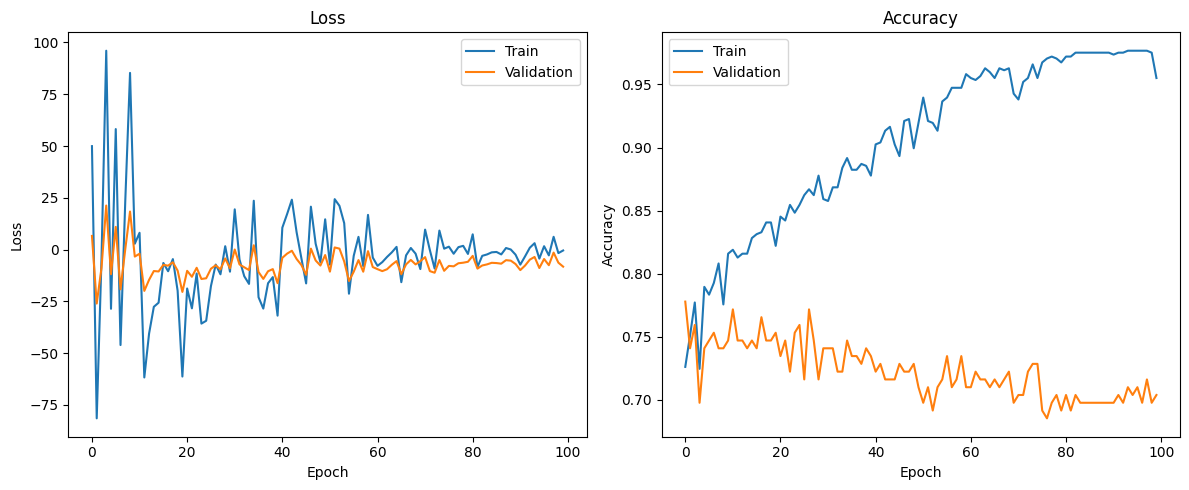

Test Loss: 0.2855, Test Accuracy: 0.6413

Example predictions:
True: 18, Predicted: 913
True: 18, Predicted: 913
True: 18, Predicted: 913
True: 18, Predicted: 913
True: 18, Predicted: 913


In [68]:
# Main execution
if __name__ == "__main__":
    # Preprocess data
    preprocessor = DataPreprocessor()
    preprocessor.preprocess()

    # Initialize and train model
    input_size = preprocessor.X_train.shape[1]
    hidden_size = 10
    output_size = 1

    model = MLP(input_size, hidden_size, output_size)
    trainer = Trainer(model, preprocessor.X_train, preprocessor.y_train,
                      preprocessor.X_val, preprocessor.y_val,
                      epochs=100, learning_rate=0.1, batch_size=32)
    trainer.train()

    # Plot training results
    trainer.plot_results()

    # Test the model
    tester = Tester(model, preprocessor.X_test, preprocessor.y_test)
    test_output = tester.test()

    # Print some example predictions
    print("\nExample predictions:")
    for i in range(5):
        true_label = np.argmax(preprocessor.y_test)
        predicted_label = np.argmax(test_output)
        print(f"True: {true_label}, Predicted: {predicted_label}")

**Explanation:**

- **Data Preprocessing:**
  - Initializes the `DataPreprocessor` and splits the data.
  
- **Model Initialization and Training:**
  - Initializes the `MLP` with appropriate sizes.
  - Creates a `Trainer` instance and trains the model.
  
- **Plotting Results:**
  - Visualizes the training and validation loss and accuracy.
  
- **Testing:**
  - Evaluates the model on the test dataset.
  - Prints example predictions to compare true and predicted labels.

---

## **5. Instructions for Completing the Assignment**

Throughout the notebook, you will encounter `##TODO` sections. Your tasks are to:

1. **Load and Merge Datasets:**
   - Use `pd.read_csv()` to load each CSV file into a DataFrame.
   - Merge the DataFrames on the `SEQN` column using `pd.merge()`.

2. **Identify and Drop Columns:**
   - Use `.nunique()` to find columns with a single unique value.
   - Drop these columns using `.drop()`.

3. **Handle Missing Values:**
   - Implement the `replace_with_nan` function to replace specific patterns with `NaN`.
   - Use `.applymap()` to apply this function across the DataFrame.
   - Drop columns with more than 30% missing values.

4. **Segregate Numerical and Categorical Variables:**
   - Identify numerical columns (typically `float64` or `int64` with many unique values).
   - Identify categorical columns (typically `object` or `int64` with few unique values).

5. **Impute Missing Values:**
   - For numerical columns, compute the median and replace `NaN` values.
   - For categorical columns, compute the mode and replace `NaN` values.

6. **Encode Categorical Variables:**
   - Use `pd.get_dummies()` to perform one-hot encoding on categorical columns.

7. **Feature Selection:**
   - Compute the correlation matrix using `.corr()`.
   - Select top features based on correlation threshold.
   - Ensure that 150 features are selected, adjusting the threshold if necessary.

8. **Scale and Apply PCA:**
   - Use `StandardScaler` to normalize the data.
   - Apply PCA to reduce dimensionality while retaining 90% variance.

9. **Encode Target Labels:**
   - Convert disease labels from `1` and `2` to `0` and `1`.

10. **Handle Class Imbalance:**
    - Use `RandomUnderSampler` to balance the classes in the training data.

11. **Implement MLP:**
    - Initialize weights and biases with appropriate dimensions and values.
    - Implement the sigmoid activation function and its derivative.
    - Perform forward and backward propagation.
    - Update weights and biases using gradients.

12. **Train and Evaluate the Model:**
    - Train the MLP using the `Trainer` class.
    - Plot the loss and accuracy curves.
    - Test the model and evaluate its performance.

---

## **Submission Guidelines**

- **Notebook Completion:** Ensure all `##TODO` sections are properly implemented.
- **Code Quality:** Write clean, readable, and well-documented code.
- **Visualizations:** Include relevant plots for EDA and training progress.
- **Report:** Summarize your findings, challenges faced, and insights gained from the model's performance.

---

Good luck with your assignment! If you have any questions or need further clarifications, feel free to reach out.